# Introduction

Fix $n \in \lbrace 2, 3 \rbrace.$ Recall the $\textbf{$n$-dimensional Rubik's Cube}$ is a cube such that each of its $6$ square faces is partitioned into $n^2$ smaller colored squares, which are known as $\textbf{stickers}.$ Each sticker takes on a color from a set of $6$ distinct colors. We refer to any state of the cube with its $6n^2$ stickers as a $\textbf{cube configuration}.$ Below are examples of 2D and 3D cube configurations, respectively.
<table><tr>
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%201.gif" alt="Drawing" style="width: 50px;"/> <figcaption class="figure-caption text-center"> An Arbitrary 2D Rubik's Cube Configuration </figcaption> 
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%201.gif" alt="Drawing" style="width: 50px;"/> <figcaption class="figure-caption text-center"> An Arbitrary 3D Rubik's Cube Configuration </figcaption>  </td>
</tr></table>


In particular, we refer to a $\textbf{solved configuration}$ as a configuration such that each square face has its $n^2$ stickers that are of the same color. Below are examples of 2D and 3D solved cube configurations, respectively.
<table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%202.gif" alt="Drawing" style="width: 50px;"/> <figcaption class="figure-caption text-center"> A Solved 2D Rubik's Cube Configuration </figcaption> 
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%202.gif" alt="Drawing" style="width: 50px;"/> <figcaption class="figure-caption text-center"> A Solved 3D Rubik's Cube Configuration </figcaption> </td>
</tr></table>

## Problem Statements

Let $\mathcal{G}_n$ be the set of all attainable $n$-dimensional cube configurations. We can transition between any two cube configurations by performing a sequence of face rotations in succession. A $\textbf{face rotation (scramble)}$ is a $90$ degree clockwise or counterclockwise rotation of a selected face.

Given a configuration $c \in \mathcal{G}_n,$ the standard puzzle is to $\textbf{solve}$ the cube, which means to find a sequence of face rotations to transform $c$ into an $n$-dimensional solved configuration. Let $m_c$ be the minimum number of face rotations needed to solve $c.$ Define $\textbf{God's Number}$ for the $n$-dimensional Rubik's cube to be the number $$M_n= \max_{c \in \mathcal{G}_n} m_c.$$ In words, God's Number is the maximum number of moves needed in order to $\textit{efficiently}$ solve the cube. We pose the following question.

* What is the value of $M_n$ ?

Next, begin with an $n$-dimensional solved configuration. For each $t \in \mathbb{N},$ define $G_t$ to be the configuration in $\mathcal{G}_n$ after performing $t$ face rotations. We pose the following questions.

* What is the probability distribution of $G_t$ ? 
* For large $t,$ is this probability distribution asymptotically discrete uniform ?

In this notebook, we answer these posed questions using tools from Group Theory and Markov Chain Theory.

In [1]:
# from google.colab import drive
# import os
# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/RubiksCubeMarkovChain')
from CubeConfiguration import *
from MarkovGraph import *
from MarkovChainCalculations import *
import matplotlib.pyplot as plt

# Cube Configurations

Fix a dimension $n \in \lbrace 2,3 \rbrace.$ We let $\mathcal{G}_n$ be the set of all attainable $n$-dimensional Rubik's cube configurations. 

## Vantage Point
Let $\mathbf{c} \in \mathcal{G}_n$ be a cube configuration. We say that two faces of $\mathbf{c}$ are $\textbf{adjacent}$ if they share a common cube edge and $\textbf{nonadjacent}$ otherwise. 

We label the $6$ faces of $\mathbf{c}$ as follows. First, choose any three pairwise adjacent faces of $\mathbf{c}$ to represent its Front (F), Left (L), and Up (U) faces. Now, let the Back (B) face of $\mathbf{c}$ be the face nonadjacent to F, the Right (R) face of $\mathbf{c}$ be the face nonadjacent to L, and the Down (D) face of $\mathbf{c}$ to be the face nonadjacent to U. 

With our labeling of faces, we define the induced $\textbf{vantage point}$ of the $\mathbf{c}$ as the viewpoint of $\mathbf{c}$ according to the diagram below. 

<figure>
<img src="https://images.saymedia-content.com/.image/c_limit%2Ccs_srgb%2Cq_auto:eco%2Cw_1200/MTc0MjYyNzAyNzY2NTY1MjQ0/rubik-cube-algorithms.webp" alt="Drawing" width="500px"/> 
    <figcaption class="figure-caption text-center"> Vantage Point of a Cube Configuration with Specified Face Orientations </figcaption>
</figure>



We say two configurations $\mathbf{c}_1$ and $\mathbf{c}_2$ in $\mathcal{G}_n$ are $\textbf{equivalent (as configurations)}$ if they are the same configuration at a certain vantage point and $\textbf{distinct}$ otherwise. For example, all solved configurations of $\mathcal{G}_n$ are equivalent to one another.  

$\textbf{Proposition}:$ The above notion of configuration equivalence is an equivalence relation on $\mathcal{G}_n.$ 


Consequently, we shall redefine $\mathcal{G}_n$ to be the set of all possible $\textit{distinct}$ $n$-dimensional Rubik's cube configurations. (Formally, each element of $\mathcal{G}_n$ is an equivalence class containing $48$ equivalent configurations).

## Standard Orientation of Faces

Let $\mathbf{c} \in \mathcal{G}_n.$ Choose a labeling of its $6$ faces following the procedure in the previous section, and position $\mathbf{c}$ according to the induced vantage point.

We specify the $\textbf{standard orientation}$ of each face M of $\mathbf{c}$: view each face M as though it were to appear in front of the screen such that:

* For F: The red arrow in the F diagram would appear above the face and pointing right.
* For L: The red arrow in the L diagram would appear to the right of the face and pointing down.
* For U: The red arrow in the U diagram would appear below the face and pointing left.
* For B: The red arrow in the B diagram would appear above the face and pointing right.
* For R: The red arrow in the R diagram would appear to left of the face and pointing up.
* For D: The red arrow in the D diagram would appear above the face and pointing right.

## Sticker Enumeration

Let $\boldsymbol{\iota}\in \mathcal{G}_n$ be the solved configuration. Choose a labeling of its $6$ faces following the procedure in the previous section, and position $\boldsymbol{\iota}$ according to the induced vantage point. Now, view each face M of $\boldsymbol{\iota}$ according to its own standard orientation, and identify M with the $n \times n$ matrix $M$ whose entries are the stickers of M. 

Enumerate the $6n^2$ total stickers of $\boldsymbol{\iota}$ from $0$ to $6n^2-1$ in row-wise fashion in the order of the faces F, L, U, B, R, and D. Finally, identify $\boldsymbol{\iota}$ with this resulting configuration with enumerated stickers.

In the code cell below, we output the face matrices of $\boldsymbol{\iota}$ with enumerated stickers as entries according to our scheme.

In [2]:
n=2
solved_cube_configuration_dict=CubeConfiguration(n).configuration_dict
for key in solved_cube_configuration_dict.keys():
    print( "{} : {}".format(key, solved_cube_configuration_dict[key]))

Front : [[0 1]
 [2 3]]
Left : [[4 5]
 [6 7]]
Up : [[ 8  9]
 [10 11]]
Back : [[12 13]
 [14 15]]
Right : [[16 17]
 [18 19]]
Down : [[20 21]
 [22 23]]


## Face Rotations 

For each face M, we define its corresponding $\textbf{clockwise face rotation}$ to be the function $\mathbf{M}: \mathcal{G}_n \rightarrow \mathcal{G}_n,$ where $\mathbf{M}(\mathbf{c})$ is the configuration obtained upon rotating the face M of the configuration $\mathbf{c}$ clockwise $90$ degrees (relative to the standard orientation of M). For each $p \in \mathbb{N},$ we also define the $\textbf{$p$-fold composition}$ of each $\mathbf{M}$ to be the function $$\mathbf{M}^p=\underbrace{\mathbf{M} \circ \ \dots \ \circ \mathbf{M}}_{p \text{ times}}.$$


$\textbf{Theorem}:$ For each face M, the following statements hold.

* $\mathbf{M}$ is a well-defined bijection with inverse $\mathbf{M}^{-1}=\mathbf{M}^3.$
* $\mathbf{M}^{-1}$ is a $\textbf{counterclockwise face rotation}$ corresponding to M.
* In the case $n=2,$ we have $\mathbf{F}^{-1}=\mathbf{B}, \ \mathbf{L}^{-1}=\mathbf{R},$ and $\mathbf{U}^{-1}=\mathbf{D}.$


In the code cell below, we output the configuration $\mathbf{F}(\iota),$ where $\iota$ is our $n$-dimensional enumerated solved configuration we obtained earlier.

In [3]:
face_name='Front'
solved_cube_configuration_rotated_front_dict=CubeConfiguration(n).rotate_face(face_name)
print("Configuration After Rotating the Solved Configuration's {} Face Clockwise:".format(face_name))
for key in solved_cube_configuration_rotated_front_dict.keys():
    print( "{} : {}".format(key, solved_cube_configuration_rotated_front_dict[key]))

Configuration After Rotating the Solved Configuration's Front Face Clockwise:
Front : [[2 0]
 [3 1]]
Left : [[ 4 20]
 [ 6 21]]
Up : [[8 9]
 [7 5]]
Back : [[12 13]
 [14 15]]
Right : [[10 17]
 [11 19]]
Down : [[18 16]
 [22 23]]


## Permutations

For each $m \in \mathbb{N},$ recall that $S_m$ as the set of bijections from $\lbrace 0, \ \dots \ , m-1 \rbrace$ to itself. It is a group under function composition.

Let $\sigma \in S_m.$ For each $p \in \mathbb{N},$ we define the $p$-th power of $\sigma$ to be the permutation $$\sigma^p=\underbrace{\mathbf{M} \circ \ \dots \ \circ \mathbf{M}}_{p \text{ times}}.$$

Recall $\kappa \in S_m$ is a $\textbf{cyclic permutation (cycle)}$ if there exist distinct numbers $j_1, \ \dots \ , j_k \in \lbrace 0, \ \dots \ , m-1 \rbrace$ such that $\kappa(j_{s})=j_{s+1}$ for all $s \in \lbrace 1, \ \dots \ , k-1 \rbrace$ and $\kappa(j_{k})=j_1.$ In this case, we adopt $\textbf{cyclic notation}$ to represent $\kappa$: we write $$\kappa = (j_1 \ \dots \ j_k).$$

We say two cycles $\kappa_1 =(j_1^{(1)} \ \dots \ j_{k_1}^{(1)})$ and $\kappa_2 =(j_2^{(2)} \ \dots \ j_{k_1}^{(2)})$ are $\textbf{disjoint}$ if the sets $\lbrace j_1^{(1)}, \ \dots \ , j_{k_1}^{(1)} \rbrace$ and $\lbrace j_1^{(2)}, \ \dots \ , j_{k_2}^{(2)} \rbrace$ are disjoint.

$\textbf{Theorem}:$ Each $\sigma \in S_m$ can be written as a composition of pairwise disjoint cycles.

## Identifying Cube Configurations with Permutations

Recall we uniquely identified our solved configuration $\boldsymbol{\iota}$ as a cube configuration with $6n^2$ enumerated stickers. Therefore, each $\mathbf{c} \in \mathcal{G}_n$ is a unique shuffling of those enumerated stickers, and so we may uniquely identify each $\mathbf{c} \in \mathcal{G}_n$ with a permutation $\sigma \in S_{6n^2}.$ 


We define the set of face rotation permutations $$\mathcal{B}_n=\left \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D}, \mathbf{F}^{-1}, \mathbf{L}^{-1}, \mathbf{U}^{-1}, \mathbf{B}^{-1}, \mathbf{R}^{-1}, \mathbf{D}^{-1} \right \rbrace,$$ where each $\mathbf{M} \in \mathcal{B}_n$ is the permutation in $S_{6n^2}$ uniquely identifying the configuration $\mathbf{M}(\boldsymbol{\iota}).$ Note that $\# \ \mathcal{B}_2=6$ and $\# \ \mathcal{B}_3=12.$


We also define the $\textbf{$n$-dimensional face rotation subgroup}$ to be the subgroup generated by $\mathcal{B}_n,$ which is explicitly the set 
$$\langle \mathcal{B}_n \rangle = \left \lbrace \mathbf{M}_1 \circ \ \dots \  \circ \mathbf{M}_k: \mathbf{M}_i \in \mathcal{B}_n,  k \in \mathbb{N} \right \rbrace.$$


$\textbf{Theorem}: $ There is a bijective correspondence between $\mathcal{G}_n$ and $\langle \mathcal{B}_n \rangle.$ 

In the code cell below, we output the permutations in $\mathcal{B}_n,$ in which each permutation is represented as a composition of disjoint cycles from $S_{6n^2}.$

In [4]:
if n==2:
    face_rotation_moves= ['F','L','U','F^-1','L^-1','U^-1'] 
    # Recall B=F^{-1}=F^3, R=L^{-1}=L^3, D=U^{-1}=U^3 in the special case n=2
else:
    face_rotation_moves= ['F','L','U','B','R','D', 'F^-1','L^-1','U^-1','B^-1','R^-1','D^-1']
face_rotation_permutations = get_face_rotation_permutations(n)

face_rotations_dict=dict(zip(face_rotation_moves, face_rotation_permutations))
for key in face_rotations_dict.keys():
    print("{} : {}".format(key, face_rotations_dict[key]))

F : (23)(0 2 3 1)(5 20 18 11)(7 21 16 10)
L : (23)(0 8 15 20)(2 10 13 22)(4 6 7 5)
U : (23)(0 16 12 4)(1 17 13 5)(8 10 11 9)
F^-1 : (23)(0 1 3 2)(5 11 18 20)(7 10 16 21)
L^-1 : (23)(0 20 15 8)(2 22 13 10)(4 5 7 6)
U^-1 : (23)(0 4 12 16)(1 5 13 17)(8 9 11 10)


# Determining God's Number via A Devil's Algorithm. 

We are ready to answer the first question we posed, which is to determine God's Number $M_n$ for the $n$-dimensional Rubik's Cube. Recall God's Number is the maximum number of moves needed to efficiently solve the cube. 

In order to do this, we iteratively construct the subgroup $\langle \mathcal{B}_n \rangle$ following a "Devil's Algorithm." We do this as follows.

* Define $\mathcal{H}_{1,n} = \lbrace \mathbf{Id}_{6n^2} \rbrace,$ where $\mathbf{Id}_{6n^2}$ is the identity permutation in $S_{6n^2}$ (which uniquely corresponds to the solved configuration $\boldsymbol{\iota}$). 
* For each $k>1,$ we define $$\mathcal{H}_{k,n} = \mathcal{H}_{k-1,n} \cup  \left \lbrace \mathbf{M} \circ \sigma: \ \sigma \in \mathcal{H}_{k-1,n}, \  \mathbf{M} \in \mathcal{B}_n \right \rbrace.$$
* We terminate the algorithm once we find a $k \in \mathbb{N}$ such that $\mathcal{H}_{k,n}=\mathcal{H}_{k-1,n}.$

$\textbf{Theorem}:$ This "Devil's Algorithm" terminates at the $k$-th iteration for some $k \in \mathbb{N}.$ For such a $k,$ we have $\mathcal{H}_{k,n}=\langle \mathcal{B}_n \rangle.$ Furthermore, the smallest such $k$ is equal to $M_n.$
 
With sheer computing power, we verified $M_2=14$ and $\# \  \mathcal{G}_2 = \# \ \langle \mathcal{B}_2 \rangle =3674160.$ Google proved that $M_3 = 20$ and $\# \  \mathcal{G}_3 = \# \ \langle \mathcal{B}_3 \rangle=43252003274489856000,$ but we do not have enough computing power to verify this. We implement this algorithm in the code cell below.

In [5]:
# try:
#     !rm -r "2D Scrambling Chain"
# except:
#     pass
# MG=MarkovGraph(n)
# max_iterations = 14
# for k in range(max_iterations):
#     print("ITERATION {}".format(k))
#     MG.update_chain()
#     print(" ")
# MG.transition_matrix

# Cube Scrambling Chain Distributions

Let $N= \#  \  \langle \mathcal{B}_n \rangle,$ and enumerate $\langle \mathcal{B}_n \rangle=\lbrace b_0, \ \dots \ , b_{N-1} \rbrace$ with $b_0=\textbf{Id}_{6n^2}.$

## Markov Chains

Let $\lbrace S_t \rbrace_{t \ge 0}$ be a collection of random variables defined on a common state space $\mathcal{S}.$ Recall $\lbrace S_t \rbrace_{t \ge 0}$ is a $\textbf{Markov Chain}$ if for all $t \ge 0,$ and all $s_0, \ \dots \ , s_{t+1} \in \mathcal{S},$ we have that 

$$\text{Pr}\left(S_{t+1} = s_{t+1} \ | \ S_{t} = s_t \right) = \text{Pr}\left(S_{t+1} = s_{t+1} \ | \ S_{t} = s_t \cap  S_{t-1}=s_{t-1} \cap \ \dots \ \cap S_0=s_0  \right),$$ where $\text{Pr}(B \ | \ A)$ denotes the conditional probability of event $B$ given the occurrence of event $A.$

In words, the probability of transitioning to a future state depends only on the current state and not on any past state. 

## Constructing the Scrambling Chain

Define $S_0$ to be the constant random variable $\textbf{Id}_{6n^2}.$ For each $t \in \mathbb{N},$ define $S_t$ to be the random variable representing the permutation obtained upon composing $t$ face rotations from $\mathcal{B}_n.$ Each random variable is defined on the common state space $\langle \mathcal{B}_n \rangle.$ We call the collection of random variables $\lbrace S_t \rbrace_{t \ge 0}$ the $\textbf{$n$-dimensional scrambling chain}.$

$\textbf{Theorem}:$ $\lbrace S_t \rbrace_{t \ge 0}$ is a Markov Chain.

## Probability Transition Matrix

Associated with this Scrambling Chain is an $N \times N$ transition matrix $P,$ whose $(i,j)$-th entry is 
$$P_{i,j}=\text{Pr}\left(S_{t+1}= b_j \ | \ S_{t}=b_i \right)$$ for all $i,j \in \lbrace 0, \ \dots  \ , N-1 \rbrace.$ Note that the entries of $P$ are actually defined independent of the value of $t.$

$\textbf{Theorem}:$  The transition matrix $P$ is a symmetric matrix i.e. $P_{i,j}=P_{j,i}$ for all $i$ and $j.$ In the case $n=2,$ each row of $P$ has exactly $6$ nonzero entries which are equal to $1/6.$ In the case $n=3,$ each row of $P$ has exactly $12$ nonzero entries which are equal to $1/12.$ 

In the code cell below, we load the corresponding $N \times N$ transition matrix $P$ in $\textbf{coordinate list (COO) format},$ which is a special type of data representation encoding the positions of the nonzero matrix entries as index triplets (see https://scipy-lectures.org/advanced/scipy_sparse/coo_matrix.html). This format makes it very suitable for sparse matrix-vector calculations.  

In [6]:
MC = MarkovChainCalculations(n)
transition_matrix = MC.transition_matrix
transition_matrix

LOADING TRANSITION MATRIX IN SPARSE COO FORMAT ... 
DONE !!!


<3674160x3674160 sparse matrix of type '<class 'numpy.float64'>'
	with 22044960 stored elements in COOrdinate format>

## Computing Explicit Scrambling Chain Distributions

For each $t \ge 0,$ we define $\pi_t$ to be the probability distribution corresponding to the random variable $S_t$ from the scrambling chain. Explicitly, for each $b \in \langle \mathcal{B}_n \rangle,$ we have $$\pi_t(b)=\text{Pr} (S_t=b).$$

$\textbf{Theorem}:$ For each $t \ge 0$ and each $i \in \lbrace 0, \ \dots \ , N-1 \rbrace,$ we have 

\begin{align*}
    \pi_{t+1}(b_i) &= \sum_{j=0}^{N-1} P_{i,j} \pi_{t}(b_j).
\end{align*}

As a matter of fact, we can recursively compute $\pi_t$ using sparse matrix-vector multiplication. For each $t \ge 0,$ denote
$$\boldsymbol{\pi}_t=(\pi_t(b_0), \ \dots \ , \pi_t(b_{N-1})) \in \mathbb{R}^N.$$ Our above theorem is equivalent to the statement
$$\boldsymbol{\pi}_{t+1} = P \boldsymbol{\pi}_t$$ for each $t \ge 0.$ 

We implement this formula in the code cell below and plot the first few chain distributions for the $n$-dimensional scrambling chain. 

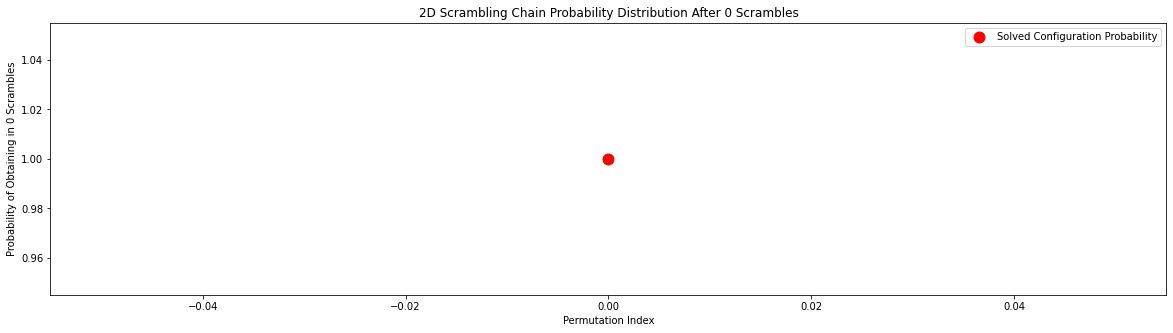

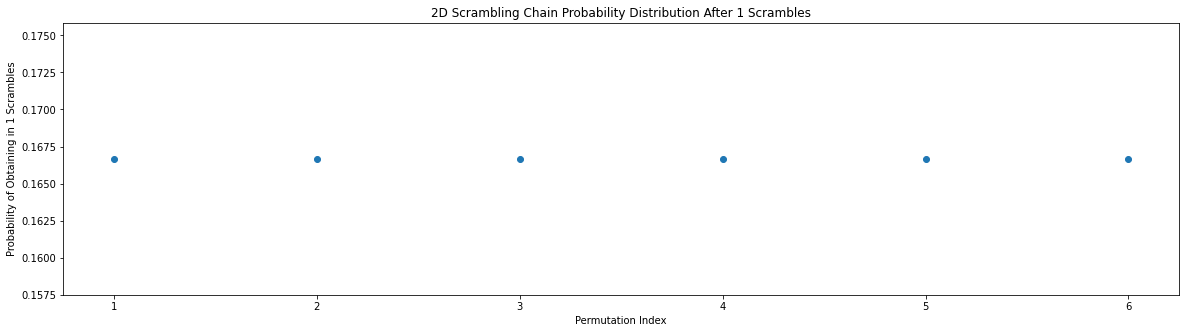

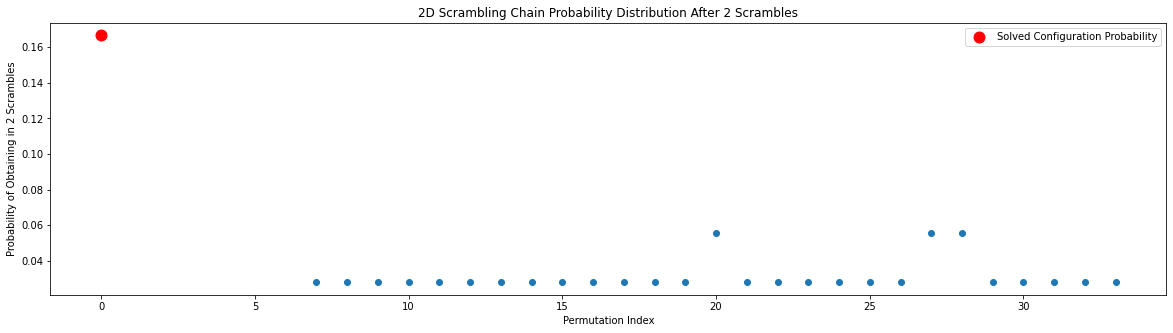

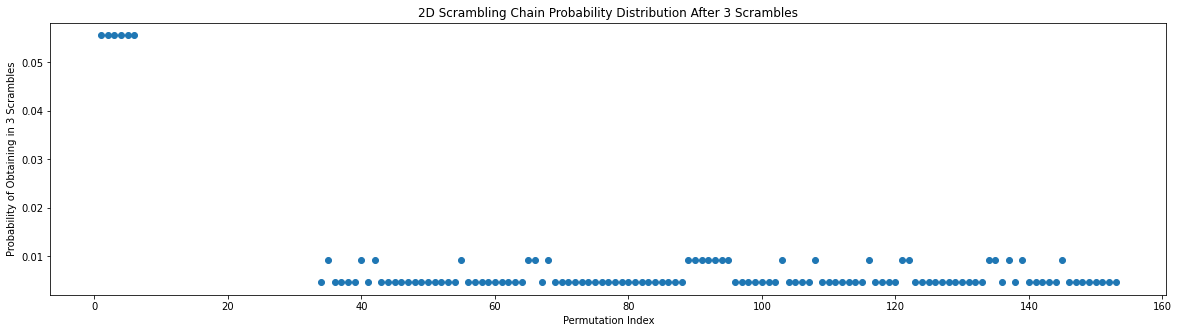

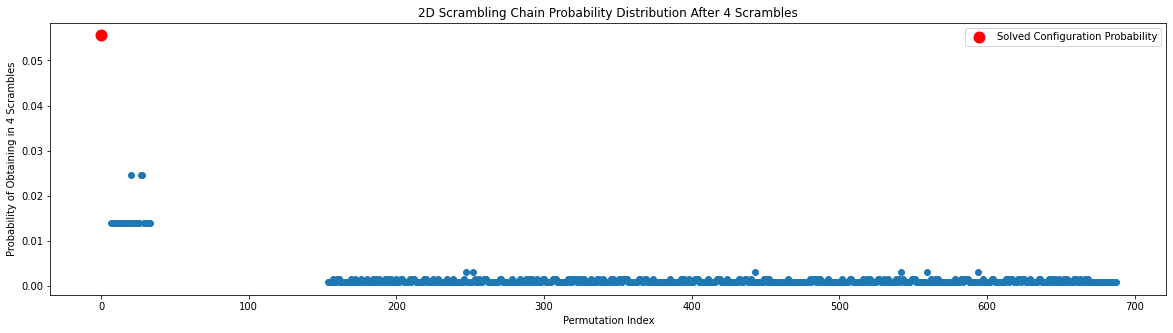

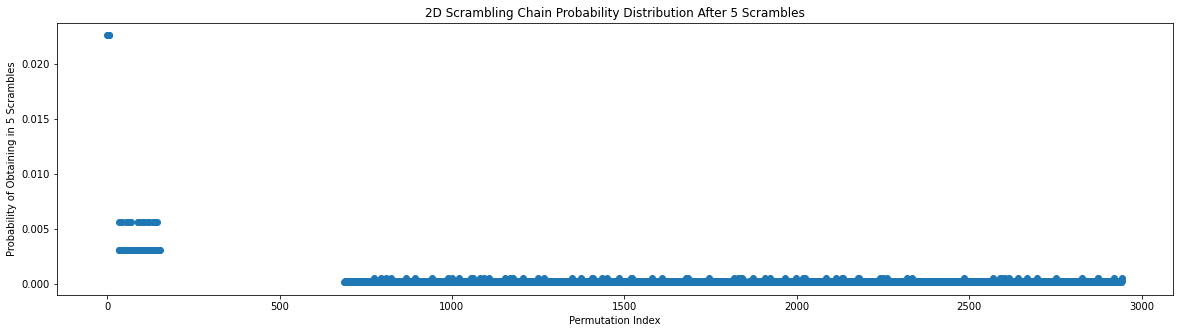

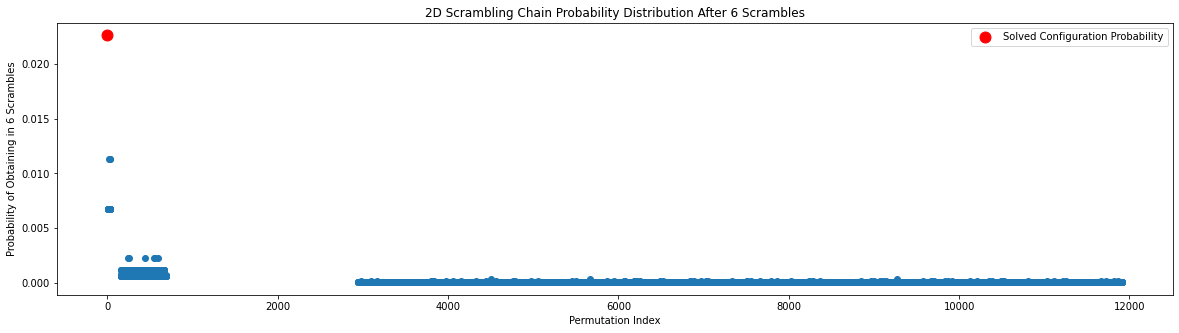

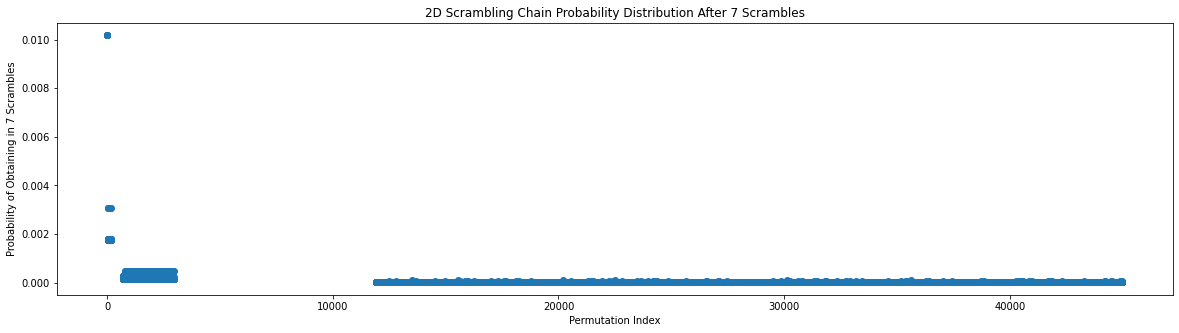

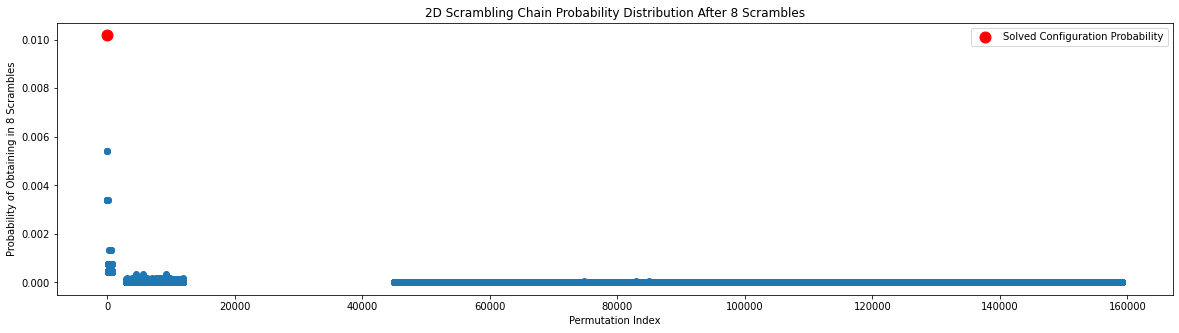

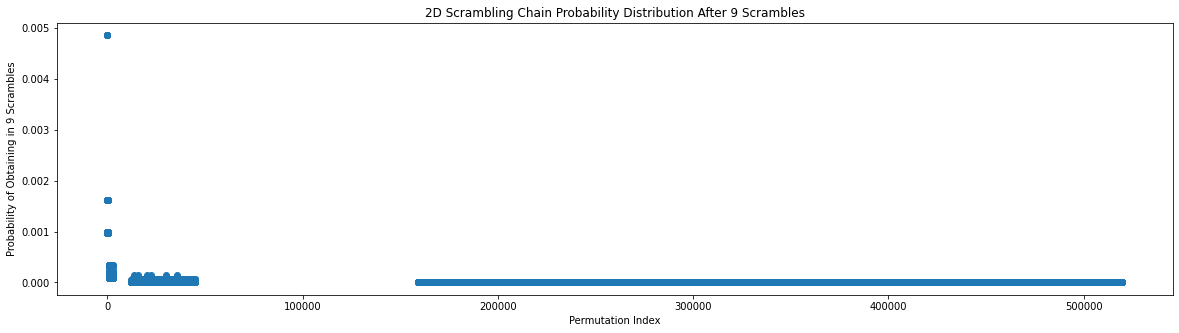

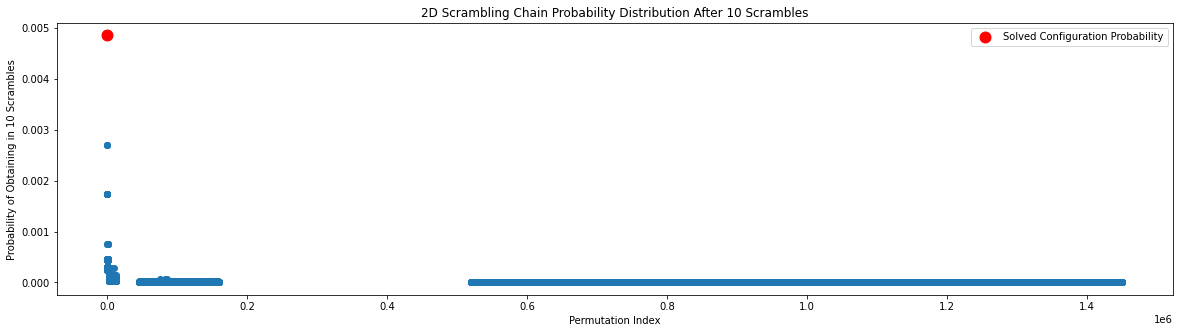

In [7]:
max_scrambles=30
for t in range(max_scrambles):
    pi_t = MC.compute_chain_distribution(t)
    if t<=10:
        fig,ax=plt.subplots(figsize=(20,5))
        permutation_indices=pi_t.nonzero()[0]
        ax.scatter(permutation_indices, pi_t.data)
        if 0 in permutation_indices:
            ax.scatter([0], pi_t.data[0],color='red',label='Solved Configuration Probability',s=120)
            ax.legend()
        ax.set_title('{}D Scrambling Chain Probability Distribution After {} Scrambles'.format(n,t))
        ax.set_xlabel('Permutation Index')
        ax.set_ylabel('Probability of Obtaining in {} Scrambles'.format(t))

$\textbf{Conjecture}:$ For even $t,$ we have that $\pi_t \left(\textbf{Id}_{6n^2} \right) > \pi_t(b)$ for all $b \in \langle \mathcal{B}_n \rangle.$ In words, after performing any even number of face rotations, we are most likely to recover the solved configuration that we initially we started with ! 

Hence, we speculate that we cannot obtain all cube configurations with equal probability. So scrambling the cube may be theoretically impossible ! 

## Computing Scrambling Chain Total Variation Distances To Discrete Uniform

Consider the discrete uniform distribution $\pi_\infty$ on $\langle \mathcal{B}_n \rangle,$ that is, $\pi_\infty(b)=1/N$ for each $b \in \langle \mathcal{B}_n \rangle $ where $N = \# \ \langle \mathcal{B}_n \rangle$ as before. 

For each $t \ge 0,$ we compute the $\textbf{total variation distance}$ between $\pi_t$ and $\pi_\infty,$ which is the quantity
$$\text{TV}(\pi_t,\pi_\infty) = \frac{\|\boldsymbol{\pi}_t - \boldsymbol{\pi}_\infty \|_1}{2} ,$$ where
$$\| \mathbf{x} \|_1= \sum_{k=0}^{N-1} |x_k|$$ for $\mathbf{x}=(x_0, \ \dots \ , x_{N-1}) \in \mathbb{R}^N$ and $\boldsymbol{\pi}_\infty=(1/N, \ \dots \ , 1/N) \in \mathbb{R}^N.$

In the code cell below, we compute and plot the first few total variation distances for the $n$-dimensional scrambling chain.

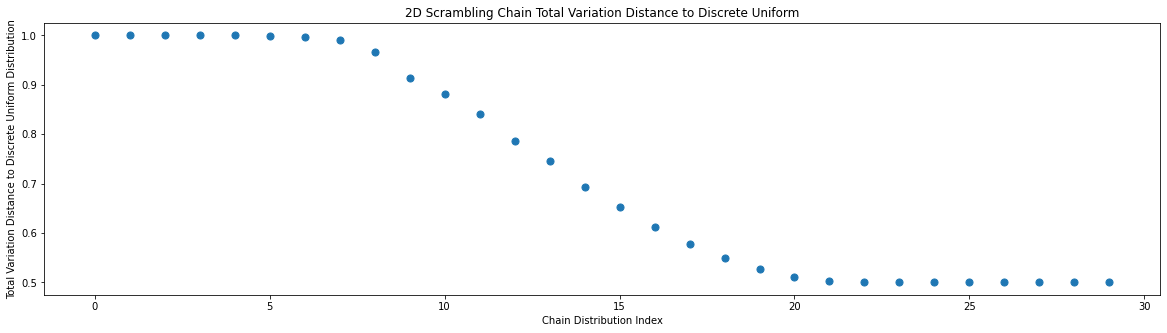

In [8]:
current_total_variation_distances_df=MC.compute_current_total_variation_distances_df()
current_total_variation_distances_df.reset_index(inplace=True)
current_total_variation_distances_df.plot.scatter(x=current_total_variation_distances_df.columns[0],
                                                  y=current_total_variation_distances_df.columns[1],
                                                  figsize=(20,5),
                                                  title='{}D Scrambling Chain Total Variation Distance to Discrete Uniform'.format(n),
                                                  s=50)

$\textbf{Conjecture}:$ We have $$\lim_{t \rightarrow \infty} \text{TV}(\pi_t,\pi_\infty) = 1/2.$$ 

So the scrambling chain distributions do not seem to be approaching the discrete uniform distribution with respect to the total variation distance. In Markov Chain terms, the discrete uniform distribution does not seem to be the correct stationary distribution of the scrambling chain. This suggests that in the long run, we will never come close to truly scrambling the cube !

# References

* Pocket Cube Devil's Algorithm: http://anttila.ca/michael/devilsalgorithm/.
* Pocket Cube Markov Chain Mixing Time Results: https://www.lifehacker.com.au/2020/01/how-hard-is-it-to-scramble-rubiks-cube/
* 3D Rubiks Cube Simulator with Sticker Labels: https://iamthecu.be/
* 2D Pocket Cube Simulator: https://www.grubiks.com/puzzles/rubiks-mini-cube-2x2x2/